# A

In [1]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-7ilcvofr
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-7ilcvofr
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done


In [2]:
import matplotlib.image as mpimg
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import json
import torch
from collections import Counter
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import clip
#from google.colab import drive
import os
from os import listdir
from os.path import isfile, join


In [3]:
def find_most_common_answer(answers):
    answer_counter = Counter(answers)
    most_common_answers = answer_counter.most_common()
    most_common_answer, count = most_common_answers[0]
    return most_common_answer

def select_most_common_answers(df):
    selected_answers = []
    for idx, row in df.iterrows():
        answers = [answer["answer"] for answer in row["answers"]]
        selected_answer = find_most_common_answer(answers)

        selected_answers.append({"answer": selected_answer
        })

    # Update the "answer" and "answer_confidence" columns in the DataFrame
    df[["answer"]] = pd.DataFrame(selected_answers)

    return df.drop(["answers"], axis=1)

def plot_loss(train_loss, val_loss):
    epochs = range(1, len(train_loss) + 1)

    plt.plot(epochs, train_loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

def plot_img(path):
    # Load the JPEG image
    image = mpimg.imread(path)

    # Plot the image
    plt.imshow(image)
    plt.axis('off')  # Remove axis ticks and labels
    plt.show()

In [4]:
def dataloader_json(path,test=False):
    # Load the JSON file
    with open(path, 'r') as f:
        data = json.load(f)
    # Create a DataFrame from the loaded JSON data
    df = pd.DataFrame(data)

    if test:
        return df

    return select_most_common_answers(df)

In [5]:
train_df = dataloader_json("norsk/train_norsk.json")

train_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,Hva er navnet på dette produktet?,other,1,basiliumblader
1,VizWiz_train_00000001.jpg,Kan du fortelle meg hva som er i denne boksen?,other,1,cola
2,VizWiz_train_00000002.jpg,Er dette enchilada saus eller er det tomater? ...,other,1,Tomater
3,VizWiz_train_00000003.jpg,Hva er captcha på dette skjermbildet?,other,1,t36m
4,VizWiz_train_00000004.jpg,Hva er dette elementet?,other,1,Solens hagelys
...,...,...,...,...,...
20518,VizWiz_train_00023949.jpg,Hva er fargen på denne laptopen?,other,1,svart
20519,VizWiz_train_00023950.jpg,"(inaudible) kan du se det? Hvis ja, så fortell...",other,1,Unødvendig
20520,VizWiz_train_00023951.jpg,Hva er de tre tallene jeg må skrive?,unanswerable,0,Unødvendig bilde
20521,VizWiz_train_00023952.jpg,Er det en boks?,yes/no,1,Nei


In [6]:
train_df['answer'].value_counts()

answer
Unødvendig       7488
Nei               508
Ja,               500
Hvit              294
Grey              286
                 ... 
10:37               1
lammelse            1
01 05 13            1
Boxer scottie       1
ipseuri ny          1
Name: count, Length: 5355, dtype: int64

In [7]:
val_df = dataloader_json("norsk/val_norsk.json")
val_df

,image,question,answer_type,answerable,answer
0,VizWiz_val_00000000.jpg,Ok. Det er et annet bilde jeg håper det er et ...,unanswerable,0,Unødvendig
1,VizWiz_val_00000001.jpg,Kan du si meg hva denne medisinen er?,other,1,nattens tid
2,VizWiz_val_00000002.jpg,Hva er tittelen på denne boken?,other,1,Hundens år
3,VizWiz_val_00000003.jpg,Hvilken er den blå?,other,1,rett
4,VizWiz_val_00000004.jpg,Hva sier pilen?,unanswerable,0,Unødvendig
...,...,...,...,...,...
4314,VizWiz_val_00004314.jpg,hva er dette?,other,1,Salat dressing
4315,VizWiz_val_00004315.jpg,Er dette moderne?,unanswerable,0,Unødvendig
4316,VizWiz_val_00004316.jpg,Jeg trenger å kjøpe dette batteriet for min tr...,unanswerable,0,Unødvendig
4317,VizWiz_val_00004317.jpg,Hva slags blanding er dette?,other,1,Kake


In [8]:
val_df['answer'].nunique()

1479

In [9]:
data_df = pd.concat((train_df,val_df), axis =0,ignore_index=True)
data_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,Hva er navnet på dette produktet?,other,1,basiliumblader
1,VizWiz_train_00000001.jpg,Kan du fortelle meg hva som er i denne boksen?,other,1,cola
2,VizWiz_train_00000002.jpg,Er dette enchilada saus eller er det tomater? ...,other,1,Tomater
3,VizWiz_train_00000003.jpg,Hva er captcha på dette skjermbildet?,other,1,t36m
4,VizWiz_train_00000004.jpg,Hva er dette elementet?,other,1,Solens hagelys
...,...,...,...,...,...
24837,VizWiz_val_00004314.jpg,hva er dette?,other,1,Salat dressing
24838,VizWiz_val_00004315.jpg,Er dette moderne?,unanswerable,0,Unødvendig
24839,VizWiz_val_00004316.jpg,Jeg trenger å kjøpe dette batteriet for min tr...,unanswerable,0,Unødvendig
24840,VizWiz_val_00004317.jpg,Hva slags blanding er dette?,other,1,Kake


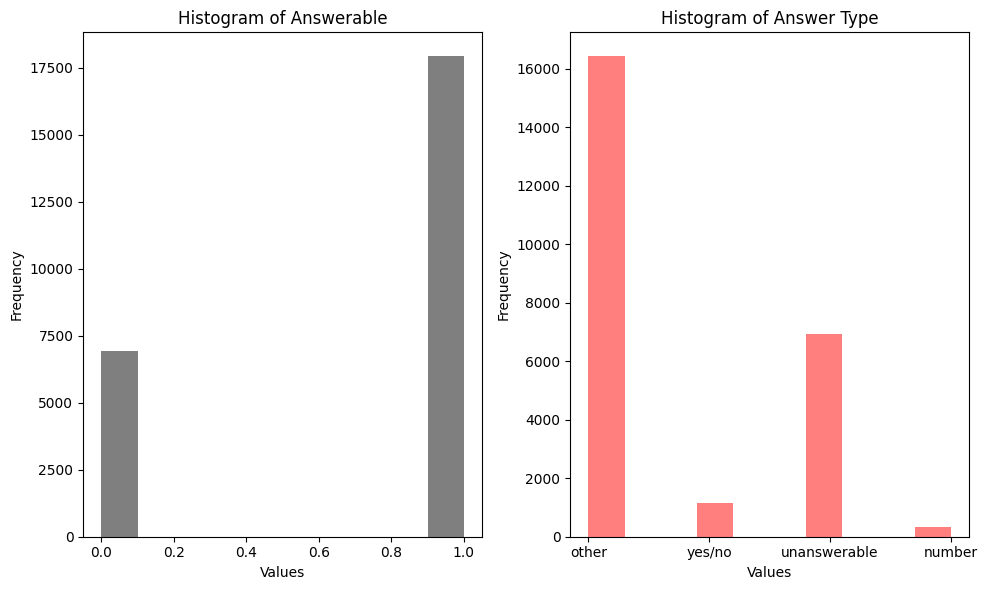

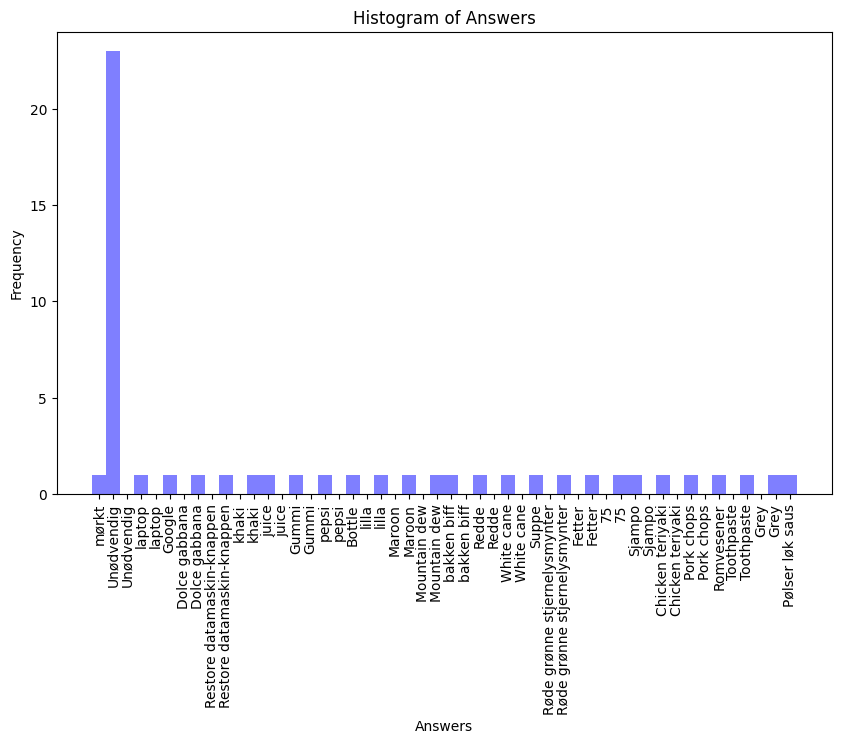

In [10]:

import matplotlib.pyplot as plt
#Create a figure with six subplots
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(10, 6))

# Plot histogram for 'answerable' with a different color
ax1.hist(pd.concat((train_df,val_df),axis = 0)['answerable'], bins=10, alpha=0.5, color='black', align='mid')
ax1.set_title('Histogram of Answerable')
ax1.set_xlabel('Values')
ax1.set_ylabel('Frequency')

# Plot histogram for 'answer_type' with a different color
ax2.hist(pd.concat((train_df,val_df),axis = 0)['answer_type'], bins=10, alpha=0.5, color='red', align='mid')
ax2.set_title('Histogram of Answer Type')
ax2.set_xlabel('Values')
ax2.set_ylabel('Frequency')

fig.tight_layout()

# Display the plot
plt.show()

# Create the histogram
plt.figure(figsize=(10, 6))  # Adjust the figure size as per your preference
counts, bins, patches = plt.hist(data_df.sample(n=50, random_state=42,replace=False)['answer'], bins=50, color='blue', alpha=0.5)

bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Customize the plot
plt.title('Histogram of Answers')
plt.xlabel('Answers')
plt.ylabel('Frequency')


plt.xticks(rotation=90)

plt.xticks(bin_centers)

max_count = max(counts)
plt.ylim(0, max_count + 1)
# Show the plot
plt.show()

In [11]:
ans_lb = LabelEncoder()
data_df['answer'] = ans_lb.fit_transform(data_df['answer'])
ans_type_lb = LabelEncoder()
data_df['answer_type']= ans_type_lb.fit_transform(data_df['answer_type'])

In [12]:
data_df

,image,question,answer_type,answerable,answer
0,VizWiz_train_00000000.jpg,Hva er navnet på dette produktet?,1,1,4592
1,VizWiz_train_00000001.jpg,Kan du fortelle meg hva som er i denne boksen?,1,1,4728
2,VizWiz_train_00000002.jpg,Er dette enchilada saus eller er det tomater? ...,1,1,4086
3,VizWiz_train_00000003.jpg,Hva er captcha på dette skjermbildet?,1,1,5991
4,VizWiz_train_00000004.jpg,Hva er dette elementet?,1,1,3700
...,...,...,...,...,...
24837,VizWiz_val_00004314.jpg,hva er dette?,1,1,3421
24838,VizWiz_val_00004315.jpg,Er dette moderne?,2,0,4228
24839,VizWiz_val_00004316.jpg,Jeg trenger å kjøpe dette batteriet for min tr...,2,0,4228
24840,VizWiz_val_00004317.jpg,Hva slags blanding er dette?,1,1,2184


In [13]:







#import os
#os.environ['CUDA_VISIBLE_DEVICES'] = '0' 
device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip, preprocess = clip.load("ViT-L/14", device=device)

print(f'Using {device}')

Using cuda


In [14]:
!pip install flax
!pip install jax[cuda11]

In [15]:
!pip install tf-keras

In [16]:
from multilingual_clip import pt_multilingual_clip
from torchvision import transforms
#import transformers
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModelForCausalLM
from transformers import T5ForConditionalGeneration, Trainer, TrainingArguments
from transformers import AutoTokenizer, AutoModelForCausalLM

#model_name ='NbAiLab/nb-t5-base-v3'
model_name='NorGLM/NorLlama-3B'

# Load Model & Tokenizer
#model = pt_multilingual_clip.MultilingualCLIP.from_pretrained(model_name)
#tokenizer= AutoTokenizer.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained("NorGLM/NorGPT-3B")
#model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)
#model = AutoModelForMaskedLM.from_pretrained("ltg/norbert3-large", trust_remote_code=True)
#model = AutoModelForSeq2SeqLM.from_pretrained("NorGLM/NorGPT-3B", trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained("NorGLM/NorGPT-3B", trust_remote_code=True)
#model = AutoModelForMaskedLM.from_pretrained("ltg/norbert3-large", trust_remote_code=True)
#model = T5ForConditionalGeneration.from_pretrained(model_name,from_flax=True)
#tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)


2025-04-09 12:22:31.234319: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-09 12:22:31.240935: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744194151.248158 1772668 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744194151.250406 1772668 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744194151.256294 1772668 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [17]:
# import torch
# #model_clip.context_length=512
# #encodings = []
# for img , question in tqdm(zip(data_df['image'],data_df['question'])):
#     if "train" in img:
#         image = preprocess(Image.open(f'train/{img}')).unsqueeze(0).to(device)
#     elif "test" in img:
#        image = preprocess(Image.open(f'test/{img}')).unsqueeze(0).to(device)
#     else:
#         image = preprocess(Image.open(f'val/{img}')).unsqueeze(0).to(device)

# encoding = tokenizer(question)


In [18]:
# # Assuming 'encoding' is already defined and has 'input_ids'
# device = "cuda" if torch.cuda.is_available() else "cpu"

# image_encoding = model_clip.encode_image(image)
# #image_encoding = image_encoding.unsqueeze(0)
# input_tensor = torch.tensor([encoding.input_ids]).to(device)
# # Move model to the same device
# model.to(device)
# text_outputs = model(**{'input_ids': input_tensor})
# # Extracting the logits from the model's output
# logits = text_outputs.logits

# # Creating the output tensor (e.g., applying softmax to get probabilities)
# output_tensor = torch.softmax(logits, dim=1)
# output_tensor = output_tensor.view(1, -1)  # Convert to shape (1, x)

# #text_outputs = model(**[encoding.input_ids])
# #output_tensor = model.generate(input_tensor, decoder_start_token_id=7, eos_token_id=8)
# #tokenizer.decode(output_tensor.squeeze(), skip_special_tokens=True)
# #output_tensor = model.generate(input_tensor, max_new_tokens=50, num_beams=4, do_sample=False)
# #tokenizer.decode(output_tensor.squeeze())
# encodings.append(torch.cat([image_encoding, output_tensor], dim=-1))

In [19]:
#len(encodings)

In [20]:
from transformers import OpenAIGPTTokenizer, OpenAIGPTModel
import torch


#### import torch
#model_clip.context_length=512
target_length=768
encodings = []
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
for img , question in tqdm(zip(data_df['image'],data_df['question'])):
    if "train" in img:
        image = preprocess(Image.open(f'train/{img}')).unsqueeze(0).to(device)
    elif "test" in img:
       image = preprocess(Image.open(f'test/{img}')).unsqueeze(0).to(device)
    else:
        image = preprocess(Image.open(f'val/{img}')).unsqueeze(0).to(device)

    encoding = tokenizer(question).to(device)

    input_tensor = torch.tensor([encoding.input_ids]).to(device)
    
    output_tensor = model.generate(input_tensor, max_new_tokens=77, decoder_start_token_id=7, eos_token_id=8).to(device)
    
    if output_tensor.shape[1] > target_length:
        # Truncate the encoding
        resized_encoding = output_tensor[:, :target_length]
    else:
        # Pad the encoding with zeros
        padding_length = target_length - output_tensor.shape[1]
        padding = torch.zeros((output_tensor.shape[0], padding_length)).to(output_tensor.device)
        resized_encoding = torch.cat((output_tensor, padding), dim=1)
   
    with torch.no_grad():
        image_encoding = model_clip.encode_image(image).to(device)
        #text_encoding = output_tensor
        #print(text_encoding.shape)
        #print(f"Image encoding device: {image_encoding.device}")
        #print(f"Text encoding device: {output_tensor.device}")

        encodings.append(torch.cat([image_encoding, resized_encoding], dim=-1))
    
    #tokenizer.decode(output_tensor.squeeze(), skip_special_tokens=True)
    # #print(question)
    # #mask_id = tokenizer.convert_tokens_to_ids("[MASK]")
    # input_text = tokenizer(question, return_tensors="pt")
    # output_p = model(**input_text)
    # #output_text = torch.where(input_text.input_ids == mask_id, output_p.logits.argmax(-1), input_text.input_ids)
    
    # input_tensor = torch.tensor(output_text).to(device)
    # # Move model to the same device
    # model.to(device)
    # text_outputs = model(input_tensor)
    # # Extracting the logits from the model's output
    # logits = text_outputs.logits
    
    # # Creating the output tensor (e.g., applying softmax to get probabilities)
    # output_tensor = torch.softmax(logits, dim=1)
    # output_tensor = output_tensor.view(1, -1)  # Convert to shape (1, x)
    

In [1]:
torch.save(encodings,"model-n.pt")


NameError: name 'torch' is not defined

In [22]:
len(encodings)

24842

In [24]:
# # Determine the maximum length
# max_length = max([encoding.shape[1] for encoding in encodings])

# # Pad the encodings
# padded_encodings = [tokenizer.pad({'input_ids': encoding}, padding='max_length', max_length=max_length, return_tensors='pt') for encoding in encodings]

# # Convert to tensors
# input_tensors = [torch.tensor(encoding['input_ids']).to(device) for encoding in padded_encodings]
# encodings=input_tensor
# torch.save(encodings,"model.pt")

In [25]:
#encd=torch.load('model-n.pt')

In [23]:
print(len(data_df))

24842


In [24]:
# Generate the indices for train-test split
indices = np.arange(len(data_df))

# Perform train-test split
train_indices, test_indices = train_test_split(indices, test_size=0.05, random_state=42)

In [25]:
train = data_df.iloc[train_indices] 
train = train.reset_index(drop=True)
train

,image,question,answer_type,answerable,answer
0,VizWiz_train_00017501.jpg,Hva er inni denne boksen?,2,0,4228
1,VizWiz_val_00003817.jpg,Hva er navnet og serienummeret til denne CCTV?,2,0,4228
2,VizWiz_train_00002858.jpg,Hvilken farge er denne skjorten?,1,1,5379
3,VizWiz_train_00004344.jpg,Hva ser jeg på?,1,1,1582
4,VizWiz_train_00014612.jpg,Kan du fortelle meg om det tok bildet av tv-st...,3,1,2110
...,...,...,...,...,...
23594,VizWiz_val_00001052.jpg,Hva sier dette?,2,0,4230
23595,VizWiz_train_00005390.jpg,Hva slags brus er dette?,1,1,2793
23596,VizWiz_train_00000860.jpg,"Er ordet Balm B-a-l-m, skrevet på denne usher-...",3,1,2863
23597,VizWiz_train_00015795.jpg,Hva sier denne skjorta?,1,1,5996


In [26]:
test = data_df.iloc[test_indices]
test = test.reset_index(drop=True)
test

,image,question,answer_type,answerable,answer
0,VizWiz_train_00005163.jpg,Er det lys eller mørk?,1,1,5531
1,VizWiz_train_00004569.jpg,Hva sier termostaten?,2,0,4228
2,VizWiz_train_00023795.jpg,Hva er dette elementet? Hvilket element er dette?,1,1,5367
3,VizWiz_val_00000320.jpg,Hva er skrevet på skjermen?,1,1,1761
4,VizWiz_train_00013788.jpg,Hvem gjør dette merket av kl,1,1,1352
...,...,...,...,...,...
1238,VizWiz_train_00003806.jpg,Hva står det på denne siden?,2,0,4228
1239,VizWiz_train_00004115.jpg,Hvilken modell er dette?,1,1,1549
1240,VizWiz_train_00004547.jpg,Hva er navnet på denne snacken?,1,1,1197
1241,VizWiz_train_00019406.jpg,Hva er i denne esken?,2,0,4228


In [27]:
embedding_size = 768#encodings[0].shape[1] #change by Arif old was 768
classes = len(np.unique(ans_lb.classes_))
aux_classes = len(np.unique(train['answer_type']))
BATCH_SIZE = 64

In [28]:
classes, aux_classes

(6178, 4)

In [29]:

encd = torch.load('model-n.pt')                             

/tmp/ipykernel_1568122/1632734083.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encd = torch.load('model-n.pt')


In [30]:
encd

[tensor([[-0.0977,  0.9229, -0.0142,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 tensor([[0.0223, 0.2235, 0.3984,  ..., 0.0000, 0.0000, 0.0000]],
        device='cuda:0'),
 tensor([[ 0.7969,  0.0390, -0.3469,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 tensor([[0.1870, 0.2686, 0.3157,  ..., 0.0000, 0.0000, 0.0000]],
        device='cuda:0'),
 tensor([[0.6836, 0.7603, 0.3728,  ..., 0.0000, 0.0000, 0.0000]],
        device='cuda:0'),
 tensor([[-0.0789,  0.9604, -0.0210,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 tensor([[-0.4128,  0.9092,  0.6504,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 tensor([[ 0.1583,  0.4614, -0.1934,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 tensor([[0.2195, 0.6108, 0.1169,  ..., 0.0000, 0.0000, 0.0000]],
        device='cuda:0'),
 tensor([[-0.3062,  1.0576,  0.3674,  ...,  0.0000,  0.0000,  0.0000]],
        device='cuda:0'),
 tensor([[ 0.7446,  0.7339, -0.0970,  ...,  

In [31]:
class dataset(Dataset):
    def __init__(self, indices, answers, types, length):
        self.indices = indices
        self.answers = answers
        self.types = types
        self.length = length

    def __getitem__(self, index):
            #print(index)
            if self.length <= 24842:
                return encd[self.indices[index]].float() , torch.tensor(int(self.answers[index])), torch.tensor(int(self.types[index]))
            
            return encd[self.indices[index]].float() , torch.tensor(int(self.answers[index % (self.length/2)])), torch.tensor(int(self.types[index % (self.length/2)]))
            
    def __len__(self):
          return self.length

In [32]:
encd[0].shape

torch.Size([1, 1536])

In [33]:
#val = data_df.iloc[24842:].reset_index(drop=True)
#val
#train_indices_aug = train_indices + 24842

In [34]:
e=torch.cat(encodings).cpu().numpy()
#trainDataset = dataset(np.concatenate((train_indices, train_indices_aug)), train['answer'], train['answer_type'], len(train_indices)*2)
trainDataset = dataset(np.array(range(train_indices.size)), train['answer'] , train['answer_type'], len(train_indices))

valDataset = dataset(np.array(range(test_indices.size)), test['answer'], test['answer_type'], len(test_indices))

#valDataset = dataset(np.array(list(range(encd.shape[0] - 5642, encd.shape[0]))), val['answer'], val['answer_type'], 4319)
#valDataset = dataset(np.array(list(range(encd.shape[0] - 5642, encd.shape[0]))), pd.DataFrame(e).iloc[24842:], val['answer_type'], 5642)

train_dataloader = DataLoader(trainDataset, batch_size = BATCH_SIZE, shuffle = True, num_workers=0)

val_dataloader = DataLoader(valDataset, batch_size = BATCH_SIZE, shuffle = True, num_workers=0)

In [35]:
len(val_dataloader)

20

In [36]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.ln1 = nn.LayerNorm(embedding_size*2)
        self.dp1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(embedding_size* 2, 512)
        
        self.ln2 = torch.nn.LayerNorm(512)
        self.dp2 = torch.nn.Dropout(0.5)
        
        self.fc2 = torch.nn.Linear(512, classes)
        
        self.fc_aux = torch.nn.Linear(512, aux_classes)
        
        self.lnaux = torch.nn.LayerNorm(aux_classes)
        self.dpaux = torch.nn.Dropout(0.5)
                
        self.fc_gate = torch.nn.Linear(aux_classes, classes)
        self.act_gate = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.ln1(x)
        x = self.dp1(x)
        
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        
        x = self.ln2(x)
        x = self.dp2(x)
        
#         aux
        aux = self.fc_aux(x)
#         aux = self.lnaux(aux)
#         aux = self.dpaux(aux)
        
#         linear bottom
        vqa = self.fc2(x)
        
        output = vqa * self.act_gate(self.fc_gate(aux))
        
        
        return output,aux

In [1]:
def run_model(model,dataloader,val_loader, optimizer,train = True ):
    if train:
        model.train()
    
    loss = nn.CrossEntropyLoss()
    
    total_loss = 0
    total_correct = 0
    total_samples = 0
    
    total_correct_ty = 0
    total_samples_ty = 0
    
    for (data, ans , ans_type) in tqdm(dataloader):
        data = data.to(device)
        ans = ans.to(device)
        ans_type = ans_type.to(device)
        optimizer.zero_grad()
        output , aux = model(data)
        
        loss_ans = loss(output, ans)
        loss_type = loss(aux,ans_type)
        loss_combined=loss_ans+loss_type
        total_loss += loss_combined.item()
        loss_combined.backward()
        optimizer.step()
        
        
#         Answer Accurracy
        _, predicted_labels = torch.max(output, dim=1)
        correct = (predicted_labels == ans).sum().item()
        total_correct += correct
        total_samples += ans.size(0)
        train_accuracy = total_correct / total_samples
        
#         Type Accuracy
        _, predicted_labels_ty = torch.max(aux, dim=1)
        correct_ty = (predicted_labels_ty == ans_type).sum().item()
        total_correct_ty += correct_ty
        total_samples_ty += ans_type.size(0)
        train_accuracy_ty = total_correct_ty / total_samples_ty
    
    total_train_accuracy = (0.7*train_accuracy + train_accuracy_ty) / 2
        
        
    if val_loader is not None:
        model.eval()

    # Initialize validation-specific variables
    val_loss = 0.0
    total_correct_val=0
    total_samples_val=0
    
    total_correct_val_ty=0
    total_samples_val_ty=0
    
    # Disable gradient calculation
    with torch.no_grad():
        # Iterate over the validation data
        for (data, ans , ans_type) in val_loader:
            data = data.to(device)
            ans = ans.to(device)
            ans_type = ans_type.to(device)
            
            # Forward pass
            output , aux = model(data)

            # Compute the loss
            loss_ans = loss(output, ans)
            loss_type = loss(aux,ans_type)
            loss_combined=loss_ans+loss_type
            val_loss += loss_combined.item()

            # Update validation metrics
            _, val_predicted = torch.max(output, dim=1)
            correct_val = (val_predicted == ans).sum().item()
            total_correct_val += correct_val
            total_samples_val += ans.size(0)
            val_accuracy = total_correct_val / total_samples_val
            
            _, val_predicted_ty = torch.max(aux, dim=1)
            correct_val_ty = (val_predicted_ty == ans_type).sum().item()
            total_correct_val_ty += correct_val_ty
            total_samples_val_ty += ans_type.size(0)
            val_accuracy_ty = total_correct_val_ty / total_samples_val_ty
        
        total_val_accuracy = (val_accuracy + val_accuracy_ty) / 2
        
    train_loss = total_loss/len(dataloader)
    val_loss = val_loss/len(val_loader)
    
    print(f"\nTrain Loss: {train_loss:.4f} | AVG Train ACC: {total_train_accuracy * 100:.4f}% | Val Loss: {val_loss:.4f} | AVG Val ACC: {total_val_accuracy * 100:.2f}%")
    
    print(f"\nTrain ANS ACC: {train_accuracy * 100:.4f}% | VAL ANS ACC: {val_accuracy * 100:.4f}% | Train TYPE ACC: {train_accuracy_ty * 100:.4f}% | VAL TYPE ACC: {val_accuracy_ty * 100:.2f}%\n")
        
    return train_loss, val_loss


In [2]:

train_dataloader

NameError: name 'train_dataloader' is not defined

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = Model()
model = model.to(device)
model = nn.DataParallel(model)
epoch = 125
training_loss = []
val_loss = []

optimizer = torch.optim.Adam(model.parameters(),1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=.1, threshold=1e-6)

early_stopping_patience = 15  # Number of epochs to wait for improvement
best_val_loss = float('inf')
epochs_without_improvement = 0

for e in range(epoch):
    print(f'Epoch: {e+1}', f'| LR: { optimizer.param_groups[0]["lr"] }')
    trLoss, vlLoss = run_model(model,train_dataloader,val_dataloader,optimizer)    
    training_loss.append(trLoss)
    val_loss.append(vlLoss)
    
    scheduler.step(vlLoss)
    
    # Check if validation loss has improved
    if vlLoss < best_val_loss:
        best_val_loss = vlLoss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Check if early stopping criteria met
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\nValidation loss hasn't improved for {early_stopping_patience} epochs. Early stopping.")
        break

Epoch: 1 | LR: 0.001


NameError: name 'train_dataloader' is not defined

In [40]:
testDataset = dataset(test_indices,test['answer'], test['answer_type'],1027)
test_dataloader = DataLoader(testDataset, batch_size=BATCH_SIZE , shuffle=True, num_workers=0)

In [41]:
loss = nn.CrossEntropyLoss()
model.eval()
test_loss = 0.0
total_correct_test=0
total_samples_test=0
    
total_correct_test_ty=0
total_samples_test_ty=0

# Disable gradient calculation
with torch.no_grad():
    # Iterate over the validation data
    for (data, ans , ans_type) in test_dataloader:
            data = data.to(device)
            ans = ans.to(device)
            ans_type = ans_type.to(device)
            # Forward pass
            output , aux = model(data)

            # Compute the loss
            loss_ans = loss(output, ans)
            loss_type = loss(aux,ans_type)
            loss_combined=loss_ans+loss_type
            test_loss += loss_combined.item()

            # Update validation metrics
            _, test_predicted = torch.max(output, dim=1)
            correct_test = (test_predicted == ans).sum().item()
            total_correct_test += correct_test
            total_samples_test += ans.size(0)
            test_accuracy = total_correct_test / total_samples_test
            
            _, test_predicted_ty = torch.max(aux, dim=1)
            correct_test_ty = (test_predicted_ty == ans_type).sum().item()
            total_correct_test_ty += correct_test_ty
            total_samples_test_ty += ans_type.size(0)
            test_accuracy_ty = total_correct_test_ty / total_samples_test_ty
        
    total_test_accuracy = (test_accuracy + test_accuracy_ty) / 2
        
        
print(f"Test TYPE ACC: {test_accuracy_ty * 100:.4f}% | Test ANS ACC: {test_accuracy * 100:.4f}% | AVG Test ACC: {total_test_accuracy * 100:.4f}% | Test Loss: {test_loss:.4f}")   

Test TYPE ACC: 67.0886% | Test ANS ACC: 34.9562% | AVG Test ACC: 51.0224% | Test Loss: 122.2569


In [42]:
e=torch.cat(encodings).cpu().numpy()
print(e)
pd.DataFrame(e).iloc()

[[-0.09771729  0.92285156 -0.0141983  ...  0.          0.
   0.        ]
 [ 0.02229309  0.22351074  0.3984375  ...  0.          0.
   0.        ]
 [ 0.796875    0.03903198 -0.34692383 ...  0.          0.
   0.        ]
 ...
 [ 0.35131836  0.5209961   0.25317383 ...  0.          0.
   0.        ]
 [ 0.34985352 -0.41088867 -0.27685547 ...  0.          0.
   0.        ]
 [-0.06811523  0.05023193  0.01113892 ...  0.          0.
   0.        ]]


In [43]:
pd.DataFrame(e).iloc()[1]

0       0.022293
1       0.223511
2       0.398438
3       0.006718
4      -0.394043
          ...   
1531    0.000000
1532    0.000000
1533    0.000000
1534    0.000000
1535    0.000000
Name: 1, Length: 1536, dtype: float32

In [44]:
range(train_indices.size)

range(0, 23599)